# Tutorial 07 — Ligands and Parameter Files

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/uw-ipd/tmol/blob/master/docs/tutorial/07_ligand_and_params.ipynb)

This tutorial loads authoritative ligand chemistry, builds a ligand-aware `PoseStack`, scores one protein-ligand complex, and refines its pocket. It also shows how TMol parameter files differ from Rosetta `.params` files.

## Learning objectives

- Load or generate ligand chemistry and extend a `ParameterDatabase`.
- Build and score a protein-ligand complex.
- Repack and minimize a local pocket.

## Before you begin

- **Prerequisites:** The core Tutorials 01–06, especially scoring, packing, and minimization.
- **Curriculum:** This is the first specialized path after 06. Continue to [08 — Nucleic acids](08_nucleic_acids.ipynb), which includes an RNA–ligand example.
- **Related:** [Ligand workflow](../user_guide/ligands.md) · [Ligand API](../api/ligand.rst)

The reported cross-mask value comes from one connected complex; it is not a binding free energy. The Rosetta writer is an interoperability aid, not a validated parameterization workflow.

## Setup

The tutorial uses checked-in structures and parameter files, so it requires no network access. It keeps two chemistry paths separate: a pinned ADA/LG1 protein–ligand complex for scoring and refinement, and an independent AMPC MOL2 preparation example for inspecting generated parameters.

In [1]:
try:
    import google.colab  # noqa: F401
except ImportError:
    IN_COLAB = False
else:
    IN_COLAB = True

if IN_COLAB:
    from urllib.request import urlopen

    exec(
        urlopen(
            "https://raw.githubusercontent.com/uw-ipd/tmol/"
            "master/docs/tutorial/colab_setup.py"
        ).read(),
        globals(),
    )
    setup_colab(
        [
            "tmol/tests/data/protein_ligand_test/ada.xtal-lig.mmff94.tmol",
            "tmol/tests/data/protein_ligand_test/ada.tmol.nomin.cif",
            "tmol/tests/data/ligand_test/ligand_ground_truth/mol2/ampc_1.mol2",
        ]
    )

In [2]:
from contextlib import redirect_stderr, redirect_stdout
from io import StringIO
from pathlib import Path
import tempfile
import warnings

import attrs
import biotite.structure as struc
import biotite.structure.io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from IPython.display import display

import tmol
from tmol.database import ParameterDatabase
from tmol.io import build_context_from_biotite, pose_stack_from_biotite
from tmol.ligand import (
    inject_params_file,
    load_params_file,
    nonstandard_residue_info_from_mol2,
    prepare_single_ligand,
    read_params_file,
    write_params_file,
)
from tmol.ops import (
    build_coord_mask_for_mask_and_interacting_atoms,
    calculate_block_pair_ddg,
    compute_block_adjacency,
    compute_block_centroids_and_furthest_dist,
)
from tmol.score import beta2016_score_function

SEED = 20260807
np.random.seed(SEED)
torch.manual_seed(SEED)
warnings.filterwarnings(
    "ignore", message=r"Sparse invariant checks are implicitly disabled.*"
)
device = (
    torch.device("cuda", torch.cuda.current_device())
    if torch.cuda.is_available()
    else torch.device("cpu")
)
LIGAND_RES_NAME = "LG1"


def show_table(frame):
    try:
        from itables import show
    except ImportError:
        return display(frame)
    return show(frame)


def ligand_block_mask(pose_stack):
    mask = torch.zeros_like(pose_stack.block_type_ind, dtype=torch.bool)
    for pose_i in range(pose_stack.n_poses):
        for block_i in range(pose_stack.max_n_blocks):
            type_i = int(pose_stack.block_type_ind[pose_i, block_i])
            if type_i < 0:
                continue
            block_type = pose_stack.packed_block_types.active_block_types[type_i]
            mask[pose_i, block_i] = block_type.name3 == LIGAND_RES_NAME
    if not bool(mask.any()):
        raise RuntimeError(f"No {LIGAND_RES_NAME} ligand block was built")
    return mask

## Two parameter representations

Prefer mmCIF/CIF for structure input, especially for protein–ligand systems: CIF chemical-component and bond tables can preserve connectivity and bond order that PDB coordinate records do not reliably encode. Retain MOL2 or prepared `.tmol` chemistry when it is the authoritative ligand source; a coordinate-only conversion cannot recover missing bond orders.

Rosetta `.params` is a line-oriented, normally one-residue format. Ligand records commonly include `ATOM`, `BOND`/`BOND_TYPE`, `CHI`, `PROTON_CHI`, `NBR_ATOM`, and `ICOOR_INTERNAL`. TMol's current Rosetta output is an **experimental syntactic export** of related records, not a Rosetta parameterization or validation workflow. In particular, the next cells expose its current TMol atom types, hard-coded Rosetta MM type `X`, and placeholder `NBR_RADIUS 999.0`. Those fields must be replaced or validated in an actual Rosetta preparation workflow before Rosetta use.

TMol's portable `.tmol` file is versioned YAML with three top-level payloads:

- `chemical`: residue atoms, bonds, internal coordinates, torsions, and properties;
- `elec`: per-atom partial charges; and
- `cartbonded`: residue-specific bonded parameters.

The same schemas are split across TMol's canonical database files at `tmol/database/default/chemical/chemical.yaml`, `tmol/database/default/scoring/elec.yaml`, and `tmol/database/default/scoring/cartbonded.yaml`. A portable `.tmol` file bundles ligand additions to those three domains; `chemical.yaml` alone is not a complete scoring parameter set.

In [3]:
repo_root = Path.cwd()
if not (
    repo_root / "tmol/tests/data/protein_ligand_test/ada.tmol.nomin.cif"
).exists():
    repo_root = Path(tmol.__file__).resolve().parents[1]
data_dir = repo_root / "tmol" / "tests" / "data" / "protein_ligand_test"
reference_tmol = data_dir / "ada.xtal-lig.mmff94.tmol"
complex_cif = data_dir / "ada.tmol.nomin.cif"
ligand_mol2 = (
    repo_root
    / "tmol"
    / "tests"
    / "data"
    / "ligand_test"
    / "ligand_ground_truth"
    / "mol2"
    / "ampc_1.mol2"
)

# This is the pinned ADA/LG1 preparation used by the complex below. The later
# AMPC MOL2 preparation is an independent pipeline demonstration.
preparation = load_params_file(reference_tmol)[0]
work_dir = Path(tempfile.mkdtemp(prefix="tmol-ligand-tutorial-"))
rosetta_path = work_dir / "LG1.params"
tmol_path = work_dir / "LG1.tmol"
write_params_file(preparation, rosetta_path, format="rosetta")
write_params_file(preparation, tmol_path, format="tmol")

print("Wrote:", rosetta_path)
print("Wrote:", tmol_path)

Wrote: /tmp/tmol-ligand-tutorial-f0c9ooit/LG1.params
Wrote: /tmp/tmol-ligand-tutorial-f0c9ooit/LG1.tmol


In [4]:
rosetta_lines = rosetta_path.read_text().splitlines()
tmol_document = yaml.safe_load(tmol_path.read_text())

print("Experimental Rosetta-syntax .params excerpt")
print("\n".join(rosetta_lines[:18]))
print("\nTMol .tmol excerpt")
print("\n".join(tmol_path.read_text().splitlines()[:18]))

records = [
    "ATOM",
    "BOND",
    "BOND_TYPE",
    "CHI",
    "PROTON_CHI",
    "NBR_ATOM",
    "NBR_RADIUS",
    "ICOOR_INTERNAL",
]
record_counts = {
    record: sum(line.startswith(record + " ") for line in rosetta_lines)
    for record in records
}
written_atoms = {
    fields[1]: {
        "export_atom_type": fields[2],
        "export_MM_type": fields[3],
        "export_partial_charge": float(fields[4]),
    }
    for line in rosetta_lines
    if line.startswith("ATOM ")
    for fields in [line.split()]
}
nbr_radius = float(
    next(line.split()[1] for line in rosetta_lines if line.startswith("NBR_RADIUS "))
)
ada_atom_frame = pd.DataFrame(
    [
        {
            "atom": atom.name,
            "TMol_atom_type": atom.atom_type,
            "pinned_partial_charge": preparation.partial_charges[atom.name],
            **written_atoms[atom.name],
            "provenance": "pinned ada.xtal-lig.mmff94.tmol",
        }
        for atom in preparation.residue_type.atoms
    ]
)
assert record_counts["BOND_TYPE"] == len(preparation.residue_type.bonds)
assert set(ada_atom_frame["export_MM_type"]) == {"X"}
assert np.array_equal(
    ada_atom_frame["TMol_atom_type"], ada_atom_frame["export_atom_type"]
)
assert nbr_radius == 999.0
assert np.allclose(
    ada_atom_frame["pinned_partial_charge"],
    ada_atom_frame["export_partial_charge"],
    atol=5e-5,
)
show_table(ada_atom_frame)
print(
    "Syntactic-export diagnostics: all MM types are X; "
    f"NBR_RADIUS is the placeholder {nbr_radius:g}."
)
format_comparison = pd.DataFrame(
    [
        {
            "representation": "experimental Rosetta-syntax .params",
            "top-level/records": ", ".join(
                f"{key}:{value}" for key, value in record_counts.items()
            ),
            "validated_use": "inspection only; not Rosetta-validated",
        },
        {
            "representation": "TMol .tmol",
            "top-level/records": ", ".join(tmol_document.keys()),
            "validated_use": "pinned input for this TMol tutorial",
        },
        {
            "representation": "Canonical split YAML",
            "top-level/records": (
                "chemical.yaml + elec.yaml + cartbonded.yaml"
            ),
            "validated_use": "TMol database organization",
        },
    ]
)
show_table(format_comparison)

Experimental Rosetta-syntax .params excerpt
NAME LG1
IO_STRING LG1 Z
TYPE LIGAND
AA UNK
ATOM C1   CR   X  -0.3020
ATOM N1   Nad3 X   0.0480
ATOM C2   CR   X   0.0360
ATOM N2   Nim  X  -0.5650
ATOM C3   CR   X   0.1410
ATOM C4   CDp  X   0.7160
ATOM O1   Oad  X  -0.5700
ATOM N3   Nad  X  -0.8000
ATOM C5   CS1  X   0.2560
ATOM C6   CSp  X   0.2800
ATOM O2   Ohx  X  -0.6800
ATOM C7   CS2  X   0.0000
ATOM C8   CS2  X   0.1430
ATOM C9   CR   X  -0.1430

TMol .tmol excerpt
version: '1.0'
chemical:
  residues:
  - name: LG1
    base_name: LG1
    name3: LG1
    io_equiv_class: LG1
    atoms:
    - {name: C1, atom_type: CR}
    - {name: N1, atom_type: Nad3}
    - {name: C2, atom_type: CR}
    - {name: N2, atom_type: Nim}
    - {name: C3, atom_type: CR}
    - {name: C4, atom_type: CDp}
    - {name: O1, atom_type: Oad}
    - {name: N3, atom_type: Nad}
    - {name: C5, atom_type: CS1}
    - {name: C6, atom_type: CSp}


Syntactic-export diagnostics: all MM types are X; NBR_RADIUS is the placeholder 999.


## The Rosetta reader is intentionally lossy

The experimental writer emits bond-order-aware `BOND_TYPE` records and copies each available partial charge into the fourth field of its `ATOM` record. It otherwise carries TMol atom-type strings into the Rosetta atom-type column, hard-codes MM type `X`, and writes `NBR_RADIUS 999.0`; it does not assign or validate Rosetta atom/MM types, neighbor geometry, or scoring behavior. Consequently, the output must not be described as a usable Rosetta parameter set.

The deliberately partial `read_params_file()` supports names, atom names/types, `BOND`/`BOND_TYPE`, `CHI`, `PROTON_CHI`, `NBR_ATOM`, and `ICOOR_INTERNAL`, but it drops the serialized `ATOM` charges and ignores unsupported Rosetta records. A `RawResidueType` reconstructed from `.params` therefore has neither TMol's separate electrostatic-charge map nor its residue-specific cartbonded parameter tables. Neither direction is a validated or lossless interconversion.

**Expected observations.** Topology counts should survive this file's write/read inspection, `BOND_TYPE` should be present, and nonzero charges should be visible in the written `ATOM` lines; charge and cartbonded rows are nevertheless absent from the reader result. Matching counts establish neither parameter-value equivalence nor usability in Rosetta.

In [5]:
partial_residue_type = read_params_file(rosetta_path)
source_residue_type = preparation.residue_type
count_pairs = [
    ("atoms", len(source_residue_type.atoms), len(partial_residue_type.atoms)),
    ("bonds", len(source_residue_type.bonds), len(partial_residue_type.bonds)),
    ("torsions / chi declarations", len(source_residue_type.torsions), len(partial_residue_type.torsions)),
    ("internal coordinates", len(source_residue_type.icoors), len(partial_residue_type.icoors)),
]
lossiness_rows = [
    {
        "field": field,
        "source_count": source_count,
        "reader_count": reader_count,
        "count_preserved": source_count == reader_count,
    }
    for field, source_count, reader_count in count_pairs
]
lossiness_rows.extend(
    [
        {
            "field": "partial-charge map",
            "source_count": len(preparation.partial_charges),
            "reader_count": 0,
            "count_preserved": False,
        },
        {
            "field": "cartbonded parameter rows",
            "source_count": sum(
                len(getattr(preparation.cartbonded_params, field.name))
                for field in attrs.fields(type(preparation.cartbonded_params))
            ),
            "reader_count": 0,
            "count_preserved": False,
        },
    ]
)
lossiness = pd.DataFrame(lossiness_rows)
show_table(lossiness)
print("Count equality checks structure, not full parameter-value equivalence.")

Count equality checks structure, not full parameter-value equivalence.


## Prepare separate AMPC chemistry from MOL2

This is an independent pipeline demonstration, not regeneration or validation of the pinned ADA/LG1 artifact above. The names are deliberately distinct: the source file is AMPC chemistry, `res_name="AMP"` makes the generated residue type `AMP`, while the unrelated pinned ADA complex uses residue name `LG1`. The next cell reads checked-in AMPC MOL2—with explicit hydrogens, Tripos bond types, an atom-level formal-charge annotation, and `MMFF94_CHARGES` partial charges—and constructs a fresh `LigandPreparation` named `AMP`. It is written for inspection but is not injected into or scored with the ADA complex. No network request or stochastic conformer generation is involved.

Keep two quantities distinct: AMPC's molecular formal charge is −1 from the source molecular graph, while its per-atom MMFF94 partial charges should sum to approximately −1 at the MOL2 text precision. TMol's generic `properties.protonation.protonation_state` string is residue-alternative metadata used by packing; a value such as `"neutral"` is **not** a molecular formal-charge calculation and must not override the source chemistry.

TMol does not infer trustworthy bond orders or charges from protein–ligand Cartesian coordinates. Preparation starts from authoritative ligand chemistry, then produces the residue type, charge map, and cartbonded parameters needed for scoring.

In [6]:
mol2_text = ligand_mol2.read_text()
assert "MMFF94_CHARGES" in mol2_text.splitlines()[:10]
assert "charge -1" in mol2_text

mol2_info = nonstandard_residue_info_from_mol2(ligand_mol2, res_name="AMP")
if mol2_info.partial_charges is None:
    raise RuntimeError("AMPC MOL2 did not expose authoritative partial charges")

# Preserve the authoritative MOL2 records before preparation. Hydrogen names may
# be regenerated, while charge transfer remains index-based.
source_atom_names = tuple(mol2_info.atom_names)
source_elements = tuple(mol2_info.elements)
source_subtypes = tuple(mol2_info.atom_array.tmol_source_subtype)
source_partial_charges = dict(mol2_info.partial_charges)

generated_preparation = prepare_single_ligand(mol2_info)
generated_tmol_path = work_dir / "AMPC.generated.tmol"
write_params_file(generated_preparation, generated_tmol_path, format="tmol")

def mol2_unity_atom_formal_charges(text, atom_names):
    """Read explicit per-atom formal charges from a TRIPOS MOL2 block."""
    lines = [line.strip() for line in text.splitlines()]
    try:
        line_index = lines.index("@<TRIPOS>UNITY_ATOM_ATTR") + 1
    except ValueError as error:
        raise RuntimeError("MOL2 has no UNITY_ATOM_ATTR formal charges") from error
    charges = {name: 0 for name in atom_names}
    while line_index < len(lines) and not lines[line_index].startswith("@<TRIPOS>"):
        if not lines[line_index]:
            line_index += 1
            continue
        atom_id, attribute_count = map(
            int, lines[line_index].split()[:2]
        )
        line_index += 1
        for _ in range(attribute_count):
            attribute, value = lines[line_index].split()[:2]
            line_index += 1
            if attribute == "charge":
                charges[atom_names[atom_id - 1]] = int(value)
    return charges


source_formal_charges = mol2_unity_atom_formal_charges(
    mol2_text, source_atom_names
)
source_formal_charge = sum(source_formal_charges.values())
source_partial_charge_sum = float(sum(source_partial_charges.values()))
generated_partial_charge_sum = float(
    sum(generated_preparation.partial_charges.values())
)
generic_protonation_metadata = (
    generated_preparation.residue_type.properties.protonation.protonation_state
)
assert source_formal_charge == -1
assert np.isclose(source_partial_charge_sum, -1.0, atol=5e-4)
assert np.isclose(
    generated_partial_charge_sum, source_partial_charge_sum, atol=1e-8
)

generated_atoms = tuple(generated_preparation.residue_type.atoms)
assert len(generated_atoms) == len(source_atom_names)
source_charge_vector = [source_partial_charges[name] for name in source_atom_names]
generated_charge_vector = [
    generated_preparation.partial_charges[atom.name] for atom in generated_atoms
]
assert np.allclose(generated_charge_vector, source_charge_vector, atol=1e-8)
ampc_atom_frame = pd.DataFrame(
    [
        {
            "source_atom": source_name,
            "generated_atom": generated_atom.name,
            "element": element,
            "source_Tripos_subtype": subtype,
            "source_formal_charge": source_formal_charges[source_name],
            "source_MMFF94_partial_charge": source_partial_charges[source_name],
            "generated_TMol_atom_type": generated_atom.atom_type,
            "generated_partial_charge": generated_preparation.partial_charges[
                generated_atom.name
            ],
        }
        for source_name, element, subtype, generated_atom in zip(
            source_atom_names,
            source_elements,
            source_subtypes,
            generated_atoms,
        )
    ]
)
show_table(ampc_atom_frame)

preparation_frame = pd.DataFrame(
    [
        {
            "pipeline_role": "independent AMPC MOL2 preparation demo",
            "residue_name": generated_preparation.residue_type.name3,
            "atoms": len(generated_preparation.residue_type.atoms),
            "bonds": len(generated_preparation.residue_type.bonds),
            "torsions": len(generated_preparation.residue_type.torsions),
            "molecular_formal_charge_from_source_graph": source_formal_charge,
            "formal_charge_provenance": (
                "MOL2 UNITY_ATOM_ATTR charge -1 / parsed source graph"
            ),
            "source_partial_charge_sum": source_partial_charge_sum,
            "generated_partial_charge_sum": generated_partial_charge_sum,
            "partial_charge_model": "MMFF94_CHARGES",
            "partial_charge_provenance": "checked-in ampc_1.mol2 atom records",
            "generic_protonation_state_metadata": generic_protonation_metadata,
            "metadata_interpretation": "not a molecular formal charge",
        }
    ]
)
show_table(preparation_frame)
print("Generated AMPC portable parameters (not used for ADA):", generated_tmol_path)

Generated AMPC portable parameters (not used for ADA): /tmp/tmol-ligand-tutorial-f0c9ooit/AMPC.generated.tmol


## Inject parameters and build one reusable context

`ParameterDatabase` values are immutable: injection returns a new database and leaves the default database unchanged. Next, derive one structure-independent `BiotitePoseBuildContext` from that extended database and construct the pose with `context=context`. This ensures that pose building and scoring share the same ligand definitions, charges, and cartbonded parameters when the same extended database is passed through the context.

**Expected observations.** The extended database has one additional ligand residue, the original database is unchanged, and the build context holds the exact extended database object. If pose construction reports an unknown `LG1`, the parameter file and build context were not threaded through the same workflow.

In [7]:
base_database = ParameterDatabase.get_default()
extended_database = inject_params_file(base_database, tmol_path)

complex_array = biotite.structure.io.load_structure(
    str(complex_cif), model=1, include_bonds=True
)
if isinstance(complex_array, struc.AtomArrayStack):
    complex_array = complex_array[0]

pose_diagnostics = StringIO()
try:
    with redirect_stdout(pose_diagnostics), redirect_stderr(pose_diagnostics):
        context = build_context_from_biotite(
            complex_array,
            device,
            param_db=extended_database,
            prepare_ligands=False,
        )
        pose_stack = pose_stack_from_biotite(
            complex_array,
            device,
            context=context,
            no_optH=True,
        )
except Exception:
    print(pose_diagnostics.getvalue())
    raise
score_function = beta2016_score_function(
    device, param_db=context.parameter_database
)

print("default residues:", len(base_database.chemical.residues))
print("extended residues:", len(extended_database.chemical.residues))
print("context reuses extended database:", context.parameter_database is extended_database)

default residues: 142
extended residues: 143
context reuses extended database: True


## AtomArray ligand and pocket queries

Biotite annotations are NumPy arrays, so ligand and pocket selections require no query-language extension. This descriptive pocket identifies protein residues with at least one heavy atom within 4.5 Å of any ligand heavy atom, then selects every atom in those complete residues. Selection stays in the rich input representation before conversion to TMol block masks.

Keep this cutoff distinct from the later protocol scopes: 4.5 Å selects complete residues for the compact pocket pose; packing uses TMol's expanded-sphere block adjacency with a 5 Å additive constant; minimization moves ligand atoms and protein side-chain atoms whose atom-level distance from the ligand is at most 5 Å.

**Expected observations.** The ligand card should isolate one `LG1` residue; the 4.5 Å pocket card should include nearby protein atoms but exclude the ligand. An empty ligand selection usually means the CIF residue name and prepared `.tmol` `name3` disagree.

In [8]:
ligand_query = complex_array.res_name == LIGAND_RES_NAME
ligand_atoms = complex_array[ligand_query]
if ligand_atoms.array_length() == 0:
    raise RuntimeError(
        f"No {LIGAND_RES_NAME} atoms found; check CIF and parameter residue names"
    )

ligand_heavy_query = ligand_query & (complex_array.element != "H")
ligand_heavy_coords = complex_array.coord[ligand_heavy_query]
all_to_ligand = complex_array.coord[:, None, :] - ligand_heavy_coords[None, :, :]
nearest_ligand_distance = np.linalg.norm(all_to_ligand, axis=-1).min(axis=1)
pocket_contact_query = (
    (~ligand_query)
    & (complex_array.element != "H")
    & (nearest_ligand_distance <= 4.5)
)
pocket_residues = sorted(
    {
        (str(chain), int(resid), str(name))
        for chain, resid, name in zip(
            complex_array.chain_id[pocket_contact_query],
            complex_array.res_id[pocket_contact_query],
            complex_array.res_name[pocket_contact_query],
        )
    }
)
pocket_query = np.zeros(complex_array.array_length(), dtype=bool)
for chain, resid, name in pocket_residues:
    pocket_query |= (
        (complex_array.chain_id == chain)
        & (complex_array.res_id == resid)
        & (complex_array.res_name == name)
    )
pocket_atoms = complex_array[pocket_query]
selection_table = pd.DataFrame(
    [
        {"selection": "ligand", "atoms": ligand_atoms.array_length(), "residues": 1},
        {"selection": "4.5 Å pocket", "atoms": pocket_atoms.array_length(), "residues": len(pocket_residues)},
    ]
)
show_table(selection_table)
display(
    tmol.selection_gallery(
        complex_array,
        {"ligand": ligand_query, "4.5 Å pocket": pocket_query},
    )
)
pocket_residues[:10]

[('', 17, 'HIS'),
 ('', 19, 'ASP'),
 ('', 58, 'LEU'),
 ('', 61, 'PHE'),
 ('', 62, 'LEU'),
 ('', 65, 'PHE'),
 ('', 66, 'ASP'),
 ('', 101, 'ARG'),
 ('', 102, 'TYR'),
 ('', 103, 'SER')]

## Score the ligand–protein interaction

Select the `LG1` block from the weighted block-pair matrix, then sum both ligand→protein and protein→ligand orientations. The result is the score-function interaction assigned between the ligand and protein in one bound complex, with no separated state, reorganization, or solvent correction; it is explicitly **not a ddG or binding free energy**.

**Expected observations.** The interaction value must be finite and the viewer should center on `LG1`. The viewer converts coordinates to PDB text for display, so ligand bonds are a geometry-oriented visualization—the CIF/`.tmol` data remain authoritative for chemistry.

In [9]:
ligand_blocks = ligand_block_mask(pose_stack)
real_blocks = pose_stack.block_type_ind >= 0
protein_blocks = real_blocks & ~ligand_blocks

block_pair_scorer = score_function.render_block_pair_scoring_module(pose_stack)
block_pair_scores = block_pair_scorer(pose_stack.coords)
interaction_score = (
    block_pair_scores[0]
    * ligand_blocks[0, :, None]
    * protein_blocks[0, None, :]
).sum() + (
    block_pair_scores[0]
    * protein_blocks[0, :, None]
    * ligand_blocks[0, None, :]
).sum()

show_table(
    pd.DataFrame(
        [
            {
                "metric": "weighted ligand–protein block-pair interaction",
                "value": float(interaction_score.detach().cpu()),
            }
        ]
    )
)

try:
    viewer = tmol.view(pose_stack, zoom_to={"resn": LIGAND_RES_NAME})
    viewer.setStyle(
        {"resn": LIGAND_RES_NAME},
        {"stick": {"colorscheme": "cyanCarbon", "radius": 0.22}},
    )
    viewer.show()
except ImportError:
    print("Install py3Dmol for the interactive ligand-pocket view.")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Refine the ligand pocket

The parameter comparison and one-complex score above establish the chemistry and accounting. This final section asks a separate local-optimization question. Packing samples protein side-chain rotamers only: the helper registers Dunbrack, fixed-amino-acid-chi, and input-conformation samplers, but no ligand-chi sampler. Although `LG1` declares chi torsions, it stays in its input conformation during packing and moves only during the following Cartesian minimization.

Three distance rules have different jobs:

1. **4.5 Å atom-to-ligand cutoff:** selects complete protein residues for the compact pocket pose.
2. **5 Å expanded-sphere adjacency constant:** packing includes blocks whose centroid distance is less than the sum of both block radii plus 5 Å. This is not an atom-to-atom 5 Å cutoff.
3. **5 Å atom-level minimization shell:** minimization moves every ligand atom plus protein side-chain atoms within 5 Å of any ligand atom.

Despite its historical name, `calculate_block_pair_ddg()` returns the weighted cross-mask block-pair interaction from one complex. The purple viewer and scope table expose the 5 Å minimization-shell preview on the input pocket, and the table separately reports the packing scope. The helper repacks first and then recomputes its atom-level 5 Å shell on the packed coordinates, so exact minimization membership can change if packing moves an atom across the cutoff.

> **Where “ddG” comes from.** Rosetta commonly uses score differences as computational $\Delta G$ or $\Delta\Delta G$ proxies: [InterfaceAnalyzer](https://docs.rosettacommons.org/docs/latest/application_documentation/analysis/interface-analyzer) compares a bound complex with separated partners, while [Cartesian ddG](https://github.com/RosettaCommons/documentation/blob/master/cartesian-ddG.md) compares independently optimized mutant and wild-type models. These are score-function differences in Rosetta energy units, not direct thermodynamic free-energy calculations. TMol's historical `calculate_block_pair_ddg()` name is looser still: it sums cross-mask block-pair terms in one complex and performs no state subtraction.

The result table therefore labels the computed quantity as a ligand–protein interaction score, and the term table shows which weighted components changed.

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

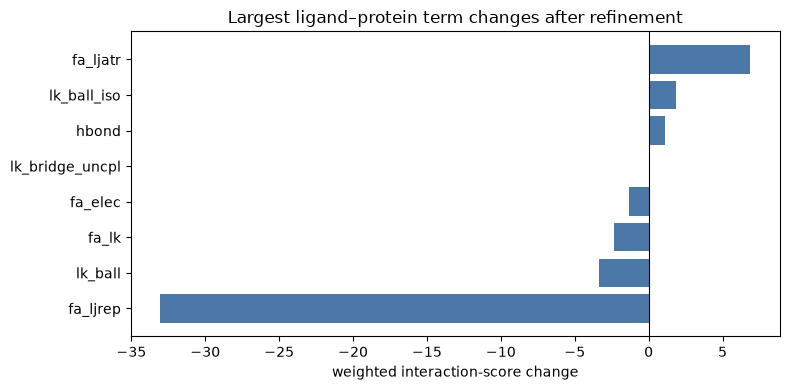

In [10]:
refinement_residues = set(pocket_residues)
protein_refinement_query = np.zeros(complex_array.array_length(), dtype=bool)
for chain, resid, name in refinement_residues:
    protein_refinement_query |= (
        (complex_array.chain_id == chain)
        & (complex_array.res_id == resid)
        & (complex_array.res_name == name)
    )
refinement_array = complex_array[ligand_query | protein_refinement_query]
refinement_diagnostics = StringIO()
try:
    with redirect_stdout(refinement_diagnostics), redirect_stderr(refinement_diagnostics):
        refinement_context = build_context_from_biotite(
            refinement_array,
            device,
            param_db=extended_database,
            prepare_ligands=False,
        )
        refinement_pose = pose_stack_from_biotite(
            refinement_array,
            device,
            context=refinement_context,
            no_optH=True,
        )
except Exception:
    print(refinement_diagnostics.getvalue())
    raise
refinement_sfxn = beta2016_score_function(
    device, param_db=refinement_context.parameter_database
)
refinement_ligand_mask = ligand_block_mask(refinement_pose)
movable_coord_mask = build_coord_mask_for_mask_and_interacting_atoms(
    refinement_pose, refinement_ligand_mask
)
refinement_centroids, refinement_radii = compute_block_centroids_and_furthest_dist(
    refinement_pose
)
packing_adjacency = compute_block_adjacency(
    refinement_centroids, refinement_radii, constant=5.0
)
packing_blocks = refinement_ligand_mask | (
    refinement_ligand_mask.unsqueeze(2) & packing_adjacency
).any(dim=1)
movable_real_atom_count = int(
    (movable_coord_mask & refinement_pose.real_atoms).sum().item()
)
ligand_atom_count = int(
    refinement_pose.n_ats_per_block[refinement_ligand_mask].sum().item()
)
show_table(
    pd.DataFrame(
        [
            {
                "complete_protein_residues_selected_at_4.5A": len(refinement_residues),
                "blocks_in_5A_expanded_sphere_pack_scope": int(packing_blocks.sum()),
                "movable_ligand_atoms": ligand_atom_count,
                "protein_sidechain_atoms_in_input_pose_5A_min_shell": (
                    movable_real_atom_count - ligand_atom_count
                ),
                "input_pose_min_shell_atoms_total": movable_real_atom_count,
            }
        ]
    )
)
try:
    movable_viewer = tmol.view(
        refinement_pose,
        highlighted=movable_coord_mask[refinement_pose.real_atoms],
        highlight_color="#7b2cbf",
    )
    movable_viewer.show()
except ImportError:
    print("Install py3Dmol to inspect the movable refinement atoms.")

torch.manual_seed(SEED)
interaction_before = calculate_block_pair_ddg(
    refinement_pose,
    refinement_ligand_mask,
    sfxn=refinement_sfxn,
    minimize=False,
    pack=False,
    database=extended_database,
)
interaction_after, refined_pose = calculate_block_pair_ddg(
    refinement_pose,
    refinement_ligand_mask,
    sfxn=refinement_sfxn,
    minimize=True,
    pack=True,
    database=extended_database,
    return_pose_stack=True,
)


def ligand_protein_scores_by_term(pose):
    scorer = refinement_sfxn.render_block_pair_scoring_module(pose)
    matrices = scorer(pose.coords, sum_terms=False, apply_weights=True)[:, 0]
    ligand = refinement_ligand_mask[0]
    protein = (pose.block_type_ind64[0] >= 0) & ~ligand
    return matrices[:, ligand][:, :, protein].sum((1, 2)) + matrices[:, protein][
        :, :, ligand
    ].sum((1, 2))


before_by_term = ligand_protein_scores_by_term(refinement_pose)
after_by_term = ligand_protein_scores_by_term(refined_pose)
torch.testing.assert_close(before_by_term.sum().reshape(1), interaction_before)
torch.testing.assert_close(after_by_term.sum().reshape(1), interaction_after)
term_frame = pd.DataFrame(
    {
        "term": [score_type.name for score_type in refinement_sfxn.all_score_types()],
        "before": before_by_term.detach().cpu().numpy(),
        "after": after_by_term.detach().cpu().numpy(),
        "delta": (after_by_term - before_by_term).detach().cpu().numpy(),
    }
)
term_frame = term_frame.loc[term_frame["delta"].abs().sort_values(ascending=False).index]
show_table(term_frame.head(10))
plot_terms = term_frame.head(8).sort_values("delta")
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(plot_terms["term"], plot_terms["delta"], color="#4c78a8")
ax.axvline(0, color="black", linewidth=0.8)
ax.set(
    xlabel="weighted interaction-score change",
    title="Largest ligand–protein term changes after refinement",
)
plt.tight_layout()
plt.show()

refinement_total_scorer = refinement_sfxn.render_whole_pose_scoring_module(
    refinement_pose
)
refined_total_scorer = refinement_sfxn.render_whole_pose_scoring_module(refined_pose)
total_before = float(refinement_total_scorer(refinement_pose.coords).detach().cpu()[0])
total_after = float(refined_total_scorer(refined_pose.coords).detach().cpu()[0])
real_atoms = refinement_pose.real_atoms & refined_pose.real_atoms
coordinate_delta = refined_pose.coords[real_atoms] - refinement_pose.coords[real_atoms]
all_real_atom_rms = float(
    torch.sqrt(torch.mean(torch.sum(coordinate_delta.square(), dim=-1))).detach().cpu()
)
movable_atoms = movable_coord_mask & real_atoms
movable_coordinate_delta = (
    refined_pose.coords[movable_atoms] - refinement_pose.coords[movable_atoms]
)
movable_atom_rms = float(
    torch.sqrt(torch.mean(torch.sum(movable_coordinate_delta.square(), dim=-1)))
    .detach()
    .cpu()
)

# The whole-pocket total contains protein intramolecular and one-body terms as
# well as ligand–protein interactions; it is not an interaction or binding score.
refinement_frame = pd.DataFrame(
    [
        {
            "stage": "input pocket",
            "whole_pocket_total_score": total_before,
            "ligand_protein_interaction": float(interaction_before.detach().cpu()[0]),
            "RMS_displacement_all_real_atoms_A": 0.0,
            "RMS_displacement_input_pose_5A_mask_atoms_A": 0.0,
        },
        {
            "stage": "repacked + minimized",
            "whole_pocket_total_score": total_after,
            "ligand_protein_interaction": float(interaction_after.detach().cpu()[0]),
            "RMS_displacement_all_real_atoms_A": all_real_atom_rms,
            "RMS_displacement_input_pose_5A_mask_atoms_A": movable_atom_rms,
        },
    ]
)
show_table(refinement_frame)
display(
    tmol.switchable_view(
        {"input pocket": refinement_pose, "refined pocket": refined_pose},
        notes={
            "input pocket": f"interaction {float(interaction_before.detach().cpu()[0]):.3f}",
            "refined pocket": (
                f"interaction {float(interaction_after.detach().cpu()[0]):.3f}; "
                f"all-real-atom RMS motion {all_real_atom_rms:.3f} Å; "
                f"input-pose 5 Å-mask atom RMS motion {movable_atom_rms:.3f} Å"
            ),
        },
    )
)

## Rosetta comparison

Rosetta `.params` files combine residue topology, atom types, charges, internal coordinates, and sampling declarations. TMol `.tmol` files mirror `ParameterDatabase`, carrying distinct chemistry, electrostatics, and cartbonded payloads in one versioned YAML document.

TMol's current Rosetta-syntax writer and partial reader are inspection aids, not a validated conversion workflow: the writer retains TMol atom types and placeholder Rosetta fields, while the reader cannot reconstruct all charge and cartbonded data. Preserve authoritative source chemistry and use Rosetta-native preparation for Rosetta workflows.

RosettaLigand and GALigandDock add global docking and protocol layers not demonstrated here. This tutorial covers parameter registration, local pocket repacking and minimization, and one-complex interaction diagnostics. See the [Rosetta-to-TMol crosswalk](rosetta_crosswalk.md) for the broader boundary.

## Next: test pose sensitivity or add mixed biopolymers

Continue to [Case Study 10 — Ligand Pose Sensitivity and Local Rescue](10_ligand_pose_sensitivity.ipynb) to score controlled rigid-body decoys in one batch and locally minimize diagnostic states. Continue to [08 — Working with DNA and RNA](08_nucleic_acids.ipynb) for protein–DNA and RNA–ligand systems.

## Exercises

1. Reload `AMPC.generated.tmol` and verify that AMPC atom names, partial charges, and cartbonded payload survive that `.tmol` round trip. Confirm that its source formal charge and partial-charge sum remain separate concepts. Do not compare it numerically with the chemically unrelated pinned ADA/LG1 artifact as a parity test.
2. Inspect which `CHI` and `PROTON_CHI` declarations survive the experimental Rosetta-syntax write/read comparison. Confirm separately that written `ATOM` charges are not retained and explain why TMol atom types, MM type `X`, and radius 999 still preclude a Rosetta-usability claim.
3. Change the 4.5 Å AtomArray pocket cutoff while leaving the two 5 Å protocol scopes unchanged, then quantify the effect on runtime and refined interaction score.
4. Separate ligand desolvation and protein desolvation contributions in the per-term interaction table.
5. Repeat pocket refinement with several packer seeds and report the interaction-score and structural spread.

## References

- [Rosetta-to-TMol crosswalk](rosetta_crosswalk.md)
- [Rosetta residue `.params` reference](https://docs.rosettacommons.org/docs/latest/rosetta_basics/file_types/Residue-Params-file)
- [Rosetta ligand-preparation tutorial](https://docs.rosettacommons.org/demos/latest/tutorials/prepare_ligand/prepare_ligand_tutorial)
- [RosettaLigand workshop slides](https://meilerlab.org/wp-content/uploads/2025/11/ligand_docking_presentation.pdf) and [2025 ligand-docking exercise](https://meilerlab.org/wp-content/uploads/2025/03/ligand_docking_tutorial.pdf)
- [Rosetta `molfile_to_params.py`](https://github.com/RosettaCommons/rosetta/blob/main/source/scripts/python/public/molfile_to_params.py)
- [PyRosettaCluster ligand-parameter workflow](https://nbviewer.org/github/RosettaCommons/PyRosetta.notebooks/blob/master/notebooks/16.10-PyRosettaCluster-Ligand-params.ipynb)
- [TMol ligand workflow](../user_guide/ligands.md)